# Spectral Methods to solve PDEs
We go from real space to Fourier space (its frequency representation).
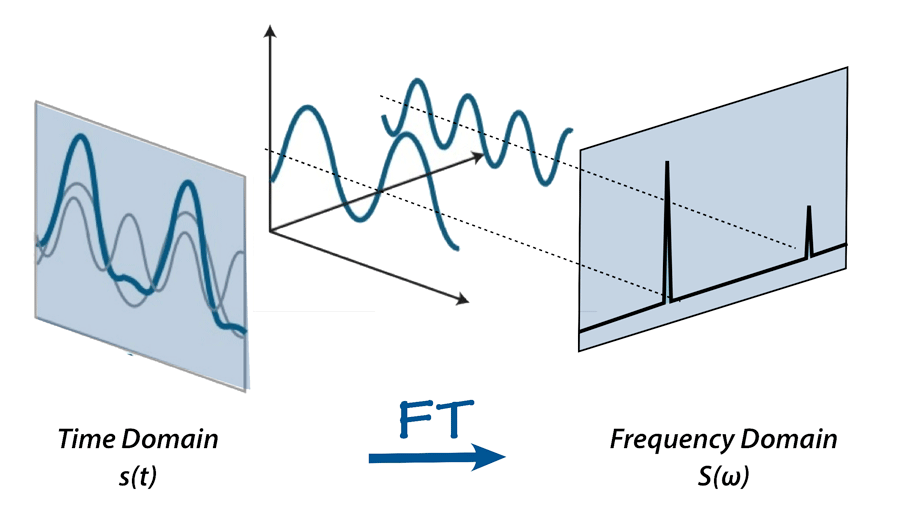

## 1D Heat Equation:
$$u_t = c² \ u_{xx}.$$
The core idea is to get the Fourier transform (in space or in time, but not both at the same time) of each term in the PDE.

**F.T in space of $u(x,t)$:**
$$u(x,t) \quad \Rightarrow \quad \mathcal{F}(u) = \hat{u}(k_x, t) = \frac{1}{\sqrt{2 \pi}} \int_{-\infty}^{+\infty} u \ e^{- \mathbf{i} k_x x} dx.$$

**F.T in space of $u_t(x,t)$:**
$$\frac{\partial u(x,t)}{\partial t} \quad \Rightarrow \quad \mathcal{F} \left( \frac{\partial u}{\partial t} \right) = \frac{d \hat{u}}{dt},$$
because,
$$\mathcal{F} \left( \frac{\partial u}{\partial t} \right) = \frac{1}{\sqrt{2 \pi}} \int_{-\infty}^{+\infty} \frac{\partial u}{\partial t} \ e^{- \mathbf{i} k_x x} dx = \frac{1}{\sqrt{2 \pi}} \frac{d}{dt}\int_{-\infty}^{+\infty} u \ e^{- \mathbf{i} k_x x} dx = \frac{d \hat{u}}{dt}.$$

**F.T in space of $u_{xx}(x,t)$:**
$$\frac{\partial² u(x,t)}{\partial x²} \quad \Rightarrow \quad \mathcal{F} \left( \frac{\partial² u}{\partial x²} \right) = - (k_x)² \ \hat{u},$$
because, using integration by parts twice,
$$
\begin{align*}
\mathcal{F}\left( \frac{\partial^2 u}{\partial x^2} \right)
&= \frac{1}{\sqrt{2 \pi}} \int_{-\infty}^{+\infty} \frac{\partial}{\partial x} \left( \frac{\partial u}{\partial x} \right) e^{- \mathbf{i} k_x x} \, dx, \\
&= -\frac{1}{\sqrt{2 \pi}} \int_{-\infty}^{+\infty} \left( \frac{\partial u}{\partial x} \right) \frac{\partial}{\partial x} \left( e^{- \mathbf{i} k_x x} \right) dx, \\
&= \frac{1}{\sqrt{2 \pi}} (\mathbf{i} k_x) \int_{-\infty}^{+\infty} \left( \frac{\partial u}{\partial x} \right) e^{- \mathbf{i} k_x x} \, dx, \\
&= -\frac{1}{\sqrt{2 \pi}} (\mathbf{i} k_x) \int_{-\infty}^{+\infty} u \, \frac{\partial}{\partial x} \left( e^{- \mathbf{i} k_x x} \right) dx, \\
&= \frac{1}{\sqrt{2 \pi}} (\mathbf{i} k_x)^2 \int_{-\infty}^{+\infty} u \, e^{- \mathbf{i} k_x x} \, dx, \\
&= (\mathbf{i} k_x)^2 \hat{u} = - (k_x)² \ \hat{u}.
\end{align*}$$

Finally, the 1D heat equation in frequency domain is,
$$
\boxed{
\frac{d \hat{u}}{dt} = -c² \ (k_x)² \ \hat{u}.
}$$
We now have a **set of ODEs**, one for each value of $k_x$.

Note that *higher frequencies decay faster because the slope is proportional to* $ \ \mathbf{-(k_x)²}$. *Thus, small-scale structure (details) in real space is smoothed out rapidly*.

A **limitation** of this approach is that the boundary conditions are implicitly encoded in the definition of a Fourier transform. Using sinusoidal modes corresponds to periodic boundary conditions, so this method is best suited for problems with periodic structure.

Non-periodic problems could be approximated by enlarging and centering the computational domain so that the boundaries are placed far away from the region of interest.

## FFT method for the heat equation:

In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt

# For solving the ODEs
import scipy.integrate as sint

### 1. Define the computational domain:

In [2]:
# Define constants
c_2 = 1.0 # difussivity constant

# The domain has to be periodic

# Length of the box/domain
L = 100.

# Discretisation of the domain
N = 1000

# Define the step size
h = L/N

# Creta the x-axis

x = np.arange(-L/2, +L/2, h)

print(x.shape)

(1000,)


### 2. Set up the ICs:

In [3]:
# Initial conditions

u_0 = np.zeros(len(x), dtype= complex) #specify datatype because of the fourier transform

#print(u_0.shape)

# Replace zeroes with cos(4*pi*x/L), alpha should be 4*pi/L. We place the sinusoidal function on the middle and zero on the edges

u_0[int((L / 2 - L / 8)/h):int((L / 2 + L / 8)/h)]  = np.cos(4*np.pi*x[int((L / 2 - L / 8)/h):int((L / 2 + L / 8)/h)]/L)

#print(u_0)

### 3. Plottingthe ICs:

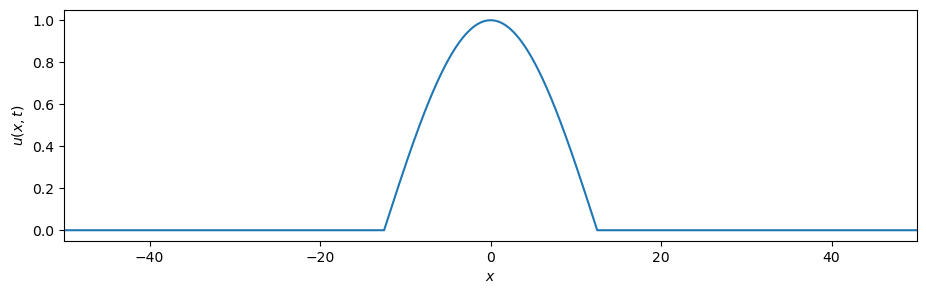

In [4]:
# Let's check with a plot of the ICs

plt.figure(figsize=(11, 3))

plt.plot(x, u_0.real)

plt.xlabel(r"$x$")
plt.ylabel(r"$u(x,t)$")

plt.xlim(-50., +50.)
plt.show()


We do this to "cheat" and use spectral method for a non-periodic signal.

## Fourier analysis:

### 4. Get the spatial frequencies for Fourier analysis:

In [5]:
# Wavenumbers = spatial frequencies:

k_numbers = 2*np.pi*np.fft.fftfreq(len(x), d = h) # BE CAREFUL TO ALWAYS DEFINE THE SPACING

#print(N, len(x))
#print(k_numbers) # ordering: 0, positive frequencies, negative frequencies.

### 5. FFT of the initial temperature profile:

In [6]:
# Fourier transform
u_0_fourier = np.fft.fft(u_0)

# Safe checks:
#print(u_0_fourier)
print(u_0.shape, u_0_fourier.shape)

(1000,) (1000,)


In [7]:
# Norm of Fourier transform
ampli_u_0_fourier = np.abs(u_0_fourier)/(u_0_fourier.size//2)

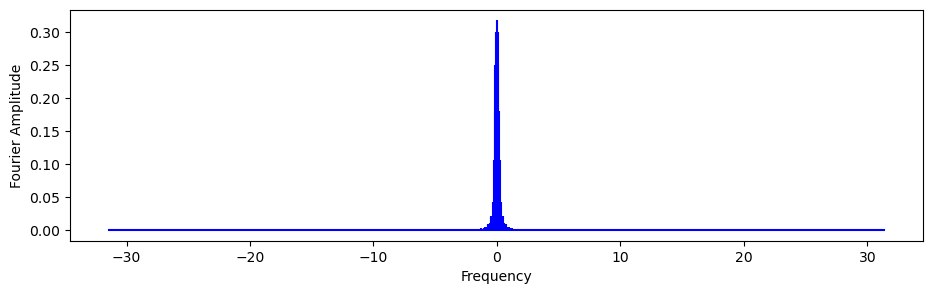

In [8]:
plt.figure(figsize = (11, 3))
plt.stem(k_numbers, ampli_u_0_fourier, 'b', markerfmt=" ", basefmt="-b")
plt.xlabel('Frequency')
plt.ylabel('Fourier Amplitude')

plt.show()

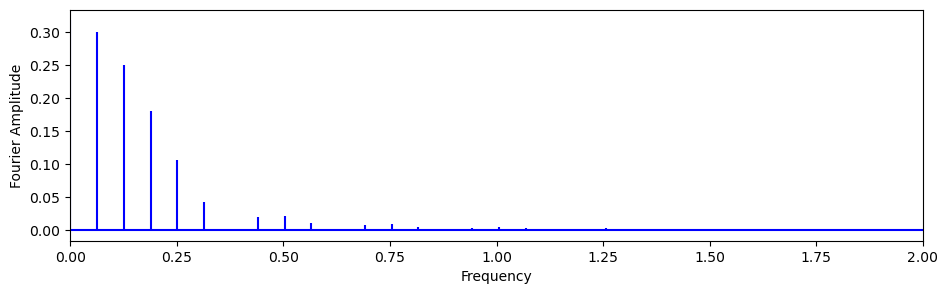

In [9]:
# Zomm-in on the positive frequencies
plt.figure(figsize = (11, 3))
plt.stem(k_numbers, ampli_u_0_fourier, 'b', markerfmt=" ", basefmt="-b")
plt.xlabel('Frequency')
plt.ylabel('Fourier Amplitude')
plt.xlim(0,2)
plt.show()

The high frequencies are related to the corners of the initial signal, the details.

### 6. Concatenate real and complex numbers:
An ODE integrator does not work with complex numbers, so we concatenate the imaginary part as real numbers.

In [10]:
# Preliminary checks:
#print(u_0_fourier)

print(u_0_fourier[3])

print(u_0_fourier[3].real)
print(u_0_fourier[3].imag)

(-90.03311260689838-1.204779137428934e-11j)
-90.03311260689838
-1.204779137428934e-11


In [11]:
# IMPORTANT: we concatenate the real and imag numbers

u_0_fourier_conc = np.concatenate((u_0_fourier.real,u_0_fourier.imag))

print(u_0_fourier_conc.shape)
print(f"Real part: {u_0_fourier_conc[3]}, Imaginary part: {u_0_fourier_conc[1003]}.")

(2000,)
Real part: -90.03311260689838, Imaginary part: -1.204779137428934e-11.


We are able to recover the complex numbers.

### 7. Time discretisation:

In [12]:
# Simulation time
b = 100.

# Time step
t_step = 1.

# Time axis:
t = np.arange(0., b, t_step)

print(t.shape)

(100,)


In [13]:
print(k_numbers.shape) 

(1000,)


## Core of the FFT analysis:

### 8. Construct ODE (RHS of ODE)
$$\frac{d \hat{u}}{dt} = -c² \ (k_x)² \ \hat{u}$$

In [14]:
# Function to get RHS

def rhs_ode(u_0_fourier_conc, t, k_numbers, c_2):
    """
    Function to calculate the slope of the k-ODEs in Fourier space.
    Inputs: 
            concatenated array with Fourier numbers -> u_0_fourier_conc (the argument has to be real)
            time axis -> t
            spatial freq/wavenumbers -> k_numbers
            diffusion coef -> c_2
    """
    # Pasting both arrays back into a single one
    # Needed to input the ODE integrator later.
    u_tilde = u_0_fourier_conc[:N] + (1j)*u_0_fourier_conc[N:]
    
    # We compute the RHS
    rhs_u_tilde = -(c_2**2)*(k_numbers**2)*u_tilde
    
    # Write the output slopes for the integrator as real numbers
    rhs_ode = np.concatenate((rhs_u_tilde.real, rhs_u_tilde.imag))
    
    return rhs_ode

In [15]:
print(rhs_ode(u_0_fourier_conc, t, k_numbers, c_2).shape)

(2000,)


### 9. Integrating our k ODEs to find the solution for ${\hat u}= {\hat T}$

In [16]:
# We call odeint (allows to solve systems of ODEs)

solution = sint.odeint(rhs_ode, u_0_fourier_conc, t, args = (k_numbers, c_2))

print(solution.shape)

(100, 2000)


### 10. Reconstruct Complex solution:

This step gives us the solution in Fourier space.

In [17]:
# Combine the first N elements (Real) with the last N elements (Imag)
# In Fourier space
u_solution = solution[:, :N] + (1j)*solution[:, N:]

print(u_solution.shape)

(100, 1000)


### 11. Inverse Fourier transform of each u_solution to go back to real space

In [18]:
# Empty sln in real space:
inv_u_solution = np.zeros(u_solution.shape, dtype = complex)

print(inv_u_solution)

[[0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 ...
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]]


In [19]:
# For loop with 'n' as index
for n in range(len(t)):
    #IFT for each element
    inv_u_solution[n, :] = np.fft.ifft(u_solution[n, :])

In [20]:
# Check the sln in real space
print(inv_u_solution) # The imaginary parts are very small

[[-7.10542736e-17+1.60927625e-31j  0.00000000e+00-2.42829032e-17j
   5.68434189e-17-3.06254740e-18j ... -5.68434189e-17-3.26926895e-17j
  -2.84217094e-17+1.76403467e-17j  0.00000000e+00+1.05856839e-17j]
 [-1.38669520e-13-1.25897877e-17j  1.38555833e-13-1.69379184e-17j
  -1.38726364e-13-1.41241673e-17j ...  1.38669520e-13-5.39744988e-17j
  -1.38669520e-13-2.35764286e-17j  1.38754785e-13-1.07375023e-17j]
 [ 3.75607101e-13-1.16548748e-17j -3.75550258e-13-3.42183964e-17j
   3.75649734e-13-1.18813379e-17j ... -3.75564468e-13-4.75476412e-17j
   3.75706577e-13-8.92839592e-18j -3.75450782e-13-2.59903545e-17j]
 ...
 [ 3.05764629e-03-2.22419314e-18j  3.05836618e-03-7.99407334e-18j
   3.06052603e-03-3.88682413e-18j ...  3.06412644e-03-1.81985945e-17j
   3.06052603e-03-1.88416132e-17j  3.05836618e-03-1.64693393e-17j]
 [ 3.20358979e-03-2.20230726e-18j  3.20432938e-03-1.81529122e-17j
   3.20654833e-03-3.33178038e-18j ...  3.21024723e-03-1.61270968e-17j
   3.20654833e-03-3.96926094e-18j  3.20432938e-

### 12. Plotting the solution:

#### A. Temperature-position plot:

In [21]:
# Check the BCs
print(inv_u_solution[79, -1])
print(inv_u_solution[99, -1])

(0.0010915713011359857-5.907306472872452e-18j)
(0.003354232233109343-1.6897097451947243e-17j)


/home/prostofosund/anaconda3/envs/py12/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/prostofosund/anaconda3/envs/py12/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


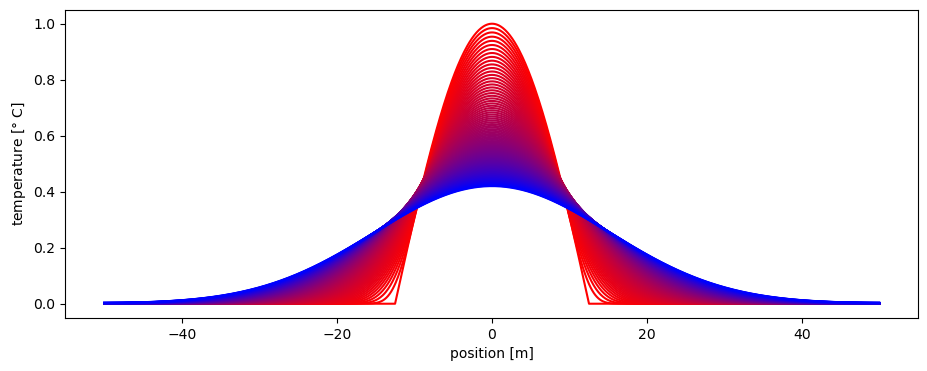

In [22]:
# Add colour

# Number of elements in the time axis:
m = len(t)

# Create our RGB scheme using 'm'
R = np.linspace(1, 0, m)
G = 0
B = np.linspace(0, 1, m)

# Fig. Environment:
plt.figure(figsize= (11, 4))

for j in range(m):
    plt.plot(x, inv_u_solution[j, :], color = [R[j], G, B[j]])

plt.xlabel("position [m]")
plt.ylabel("temperature [$\degree$ C]")

plt.show()

#### B. Surface plot in 3D:

In [23]:
from mpl_toolkits.mplot3d import axes3d

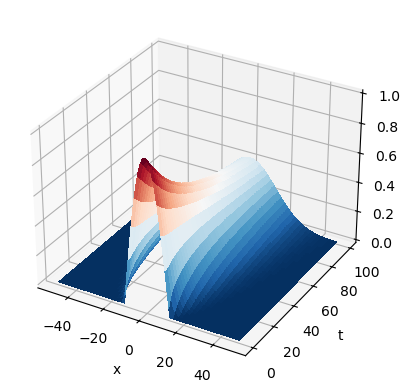

In [24]:
# Grid
x_grid, t_grid = np.meshgrid(x, t)

# Plot
fig = plt.figure()

ax = plt.axes(projection='3d')
#ax.contour3D(x_grid, t_grid, u, 1000, cmap='viridis')
# Creates 'n=10' contours at different Z to make the surface

ax.plot_surface(x_grid, t_grid, inv_u_solution.real, cmap='RdBu_r', linewidth=0, antialiased=False)

ax.set_xlabel('x')  # Customised labels for axes
ax.set_ylabel('t')
ax.set_zlabel('T')

plt.show()

#### C. 2D projection of the surface onto the x vs. t plane

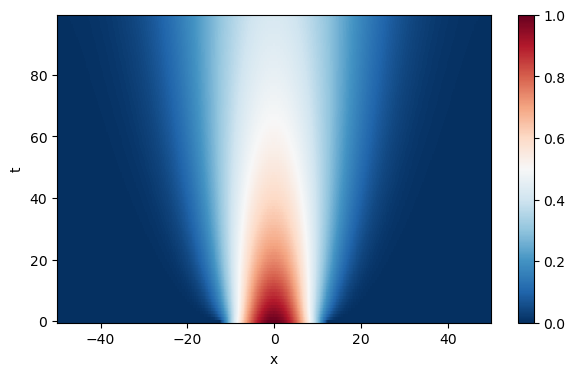

In [25]:
plt.figure(figsize= (7, 4))

#ax = plt.axes(projection='3d')
#ax.contour3D(x_grid, t_grid, u, 1000, cmap='viridis') # Creates 'n=10' contours at different Z to make the surface

z_temp = plt.pcolor(x_grid, t_grid, inv_u_solution.real, cmap='RdBu_r')

plt.colorbar(z_temp)

plt.xlabel('x')
plt.ylabel('t')
#plt.zlabel('T')

plt.show()